# Top-NMF: Appendix 1

# Import Libraries

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from sklearn.decomposition._nmf import _initialize_nmf
from tqdm.notebook import tqdm

from TopNMF import *
from cubical_complex import *

device = 'cpu'

2025-12-08 04:29:18.950012: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765135758.960935  128090 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765135758.964303  128090 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-08 04:29:18.975971: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Generate Ichimatsu Patterns

In [4]:
def create_ichimatsu_pattern(num_samples=100,image_shape = (36, 36),pat=None,pat_step=3,min_pat=10,max_pat=30,binarize=False, seed=42):
    random.seed(seed)
    X=[]
    for _ in range(num_samples):
        x = np.zeros(image_shape)
        for _ in range(random.randint(min_pat, max_pat)):
            cx = pat_step*random.randint(0, (image_shape[0]-pat.shape[0])//pat_step)
            cy = pat_step*random.randint(0, (image_shape[1]-pat.shape[1])//pat_step)
            x[cx:(cx+pat.shape[0]),cy:(cy+pat.shape[1])] += pat
            #print(cx,cy,x)
            if binarize:
                x=x>0
        X.append(x)
    return(np.array(X).astype(np.float64))

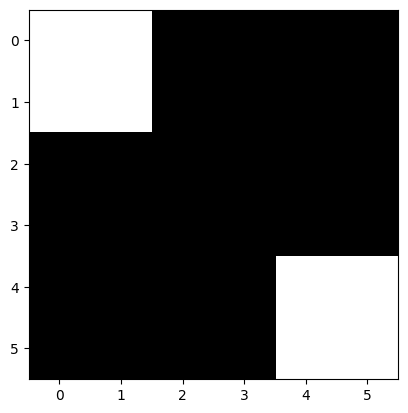

In [5]:
pat=np.zeros((6,6))
pat[0:2,0:2]=1
pat[4:6,4:6]=1

plt.imshow(pat, cmap='gray')

(40, 9, 9) (40, 32) (32, 81)


array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

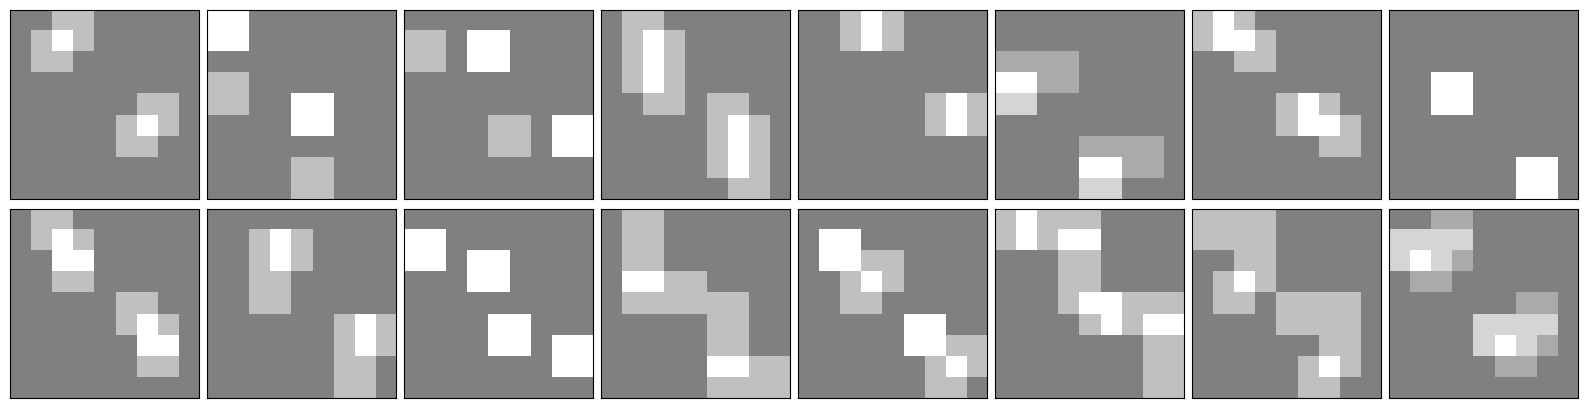

In [6]:
X = create_ichimatsu_pattern(num_samples=40,image_shape = (9, 9),pat=pat,pat_step=1,min_pat=2,max_pat=5, seed=42)
X /= np.max(X, axis=(1, 2), keepdims=True)
n_components = 32
n_samples = X.shape[0]
data_dims = X.shape[1:]
n_features = X[0].size
W, V = _initialize_nmf(X.reshape(n_samples,-1), n_components=n_components, init='nndsvdar', random_state=42)
print(X.shape, W.shape, V.shape)
plot_gallery(X, n_row=2, n_col=8)

# Run Top-NMF

  0%|          | 0/5000 [00:00<?, ?it/s]

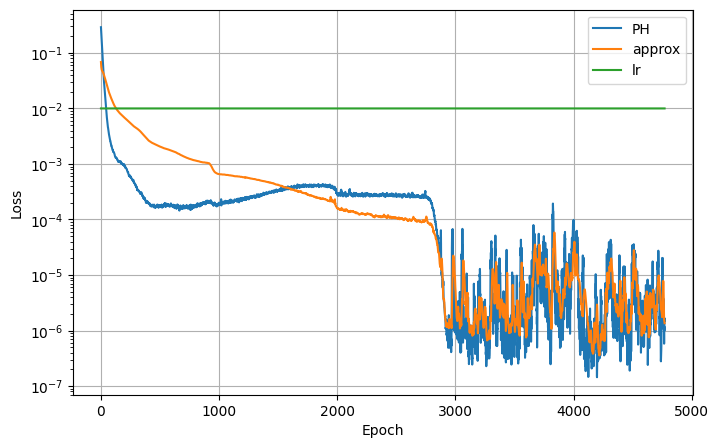

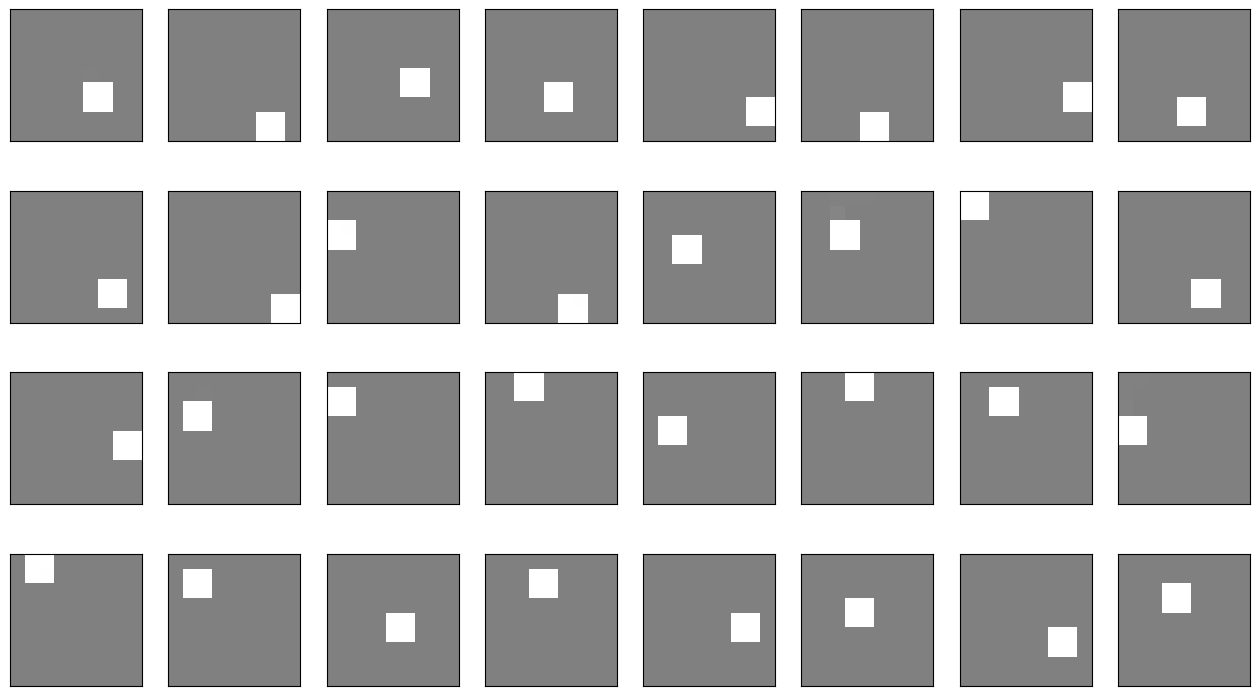

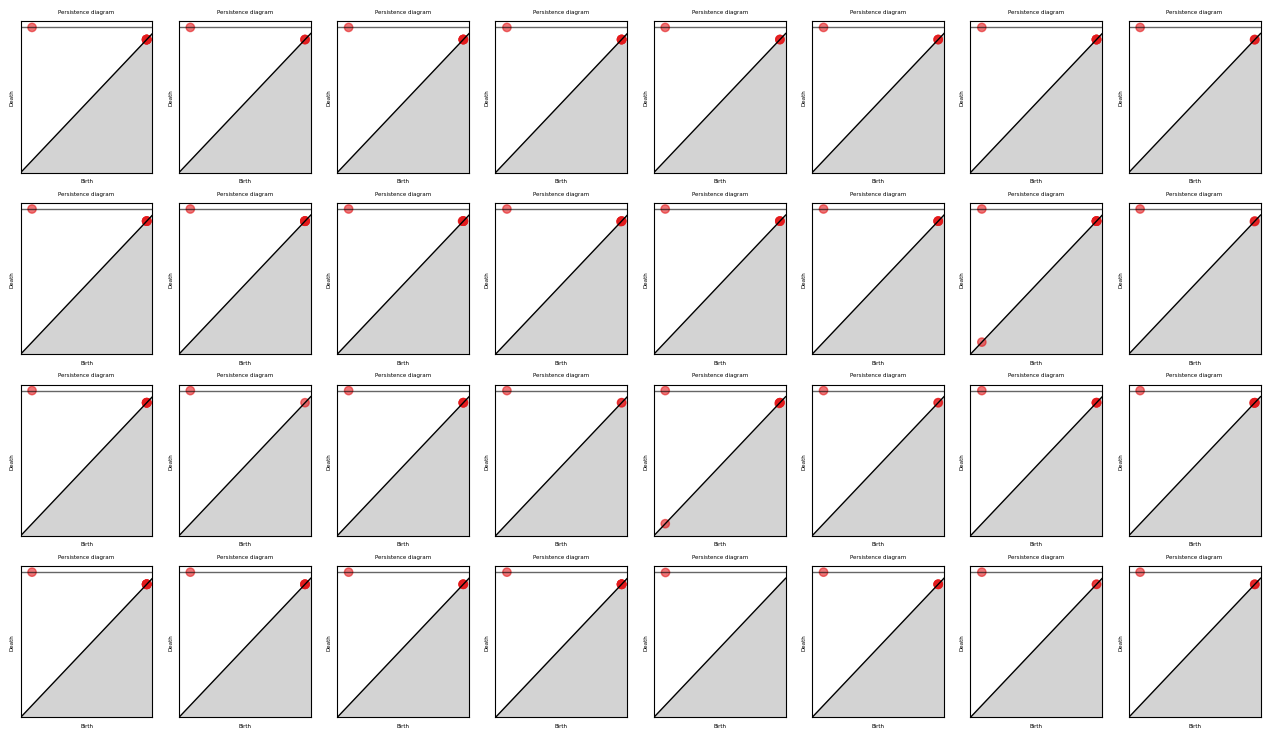

/home/keunsu/.local/lib/python3.10/site-packages/gudhi/persistence_graphical_tools.py:112: UserWarning: usetex mode requires dvipng.
  warnings.warn("usetex mode requires dvipng.")


In [7]:
# fit
lr = 0.01 # learning rate for gradient descent  (Adam: 0.1, SGD: 5)
target_sparsity = None # set to None, if you are not using
epsilon = 1e-10 # for numerical stability
PHmode = "V" # T or V construction
superlevel = True

## specify target PH (or set to None for sparsity)
target_PH = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]

gd_iter = 1 # gradient descent update per iteration
mu_iter = 0 # multiplicative update per iteration
W_iter = 1 # W update per multiplicative update iteration
start_epoch_sparsify =0 # from this epoch, start sprase_opt
start_epoch_topological=0 # from this epoch, start loss_PH optimisation
show_plots = ["loss","basis","PH"] # ["loss","basis","PH"]

lambda_top = 0.6 # 0.5 # top-NMF   # around 0.001
weight_decay = 0.1

init_optimizer = True
normalise = False

## filtration
cpx = CubicalComplex(superlevel=superlevel,dim=len(data_dims),mode=PHmode)


##
n_row, n_col = 4 , 8 # display
n_iterations = 5000
PH_dims = [0,1] # which dim to look at in PH
tol = 1e-4 # early stopping
tol_count = 30000 # early stopping
disp_interval = 10

loss_fn = torch.nn.MSELoss() # approximation error
# loss_fn = torch.nn.HuberLoss() # approximation error



##
X = torch.as_tensor(X.reshape(n_samples,-1), dtype=torch.float, device=device)
W = torch.tensor(W, dtype=torch.float, device=device, requires_grad=True)
V = torch.tensor(V, dtype=torch.float, device=device, requires_grad=True)
Vns = []
if normalise:
    with torch.no_grad():
        V /= (torch.norm(V, p=2, dim=1, keepdim=True)+epsilon)


## initialise optimiser
if init_optimizer:
    opt = optim.AdamW([W, V], lr=lr, weight_decay=weight_decay) # SGD, Adam, AdamW(weight decay for sparsity), or NAdam?
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.9, patience=1000)



## optimisation iteration
progress = tqdm(range(n_iterations))
prev_loss = np.inf
count = 0
losses = {"PH":[], "approx":[], "lr":[]}


# prepare figures
if "loss" in show_plots:
    fig_L,axs_L = plt.subplots(1,1,figsize=(8,5))
    disp_L = display(fig_L,display_id=True)
if "basis" in show_plots:
    fig_V,axs_V = plt.subplots(n_row,n_col, figsize=(2. * n_col, 2.26 * n_row))
    disp_V = display(fig_V,display_id=True)
if "PH" in show_plots:
    fig_P,axs_P = plt.subplots(n_row,n_col, figsize=(2. * n_col, 2.26 * n_row), squeeze=False)
    disp_P = display(fig_P,display_id=True)

## main iteration
for epoch in progress:
    # multiplicative update
    with torch.no_grad():
        for _ in range(mu_iter):
            #update V
            if target_sparsity is None or epoch<start_epoch_sparsify:
                W_TX = W.T @ X
                W_TWV = W.T @ W @ V + epsilon
                V *= W_TX / W_TWV
            else:
                update_V(X, W, V, target_L1) # update "V" with target sparsity

            #update W
            for _ in range(W_iter):
                XV_T = X @ V.T
                WVV_T = W @ V @ V.T + epsilon
                W *= XV_T / WVV_T

    # gradient descent update
    for _ in range(gd_iter):
        # compute PD of rows of V
        loss_PH=torch.tensor(0., device=device)
        if target_PH is None:
            loss_PH -= n_components
      
        for j in range(n_components):
            v=V[j]
            # PH sparsity
            if lambda_top>=0:
                diags = cpx(v.reshape(data_dims))
                if target_PH is None:
                    # PH sparsity
                    PH = torch.cat([diags[dim].diagram for dim in PH_dims])
                    pers1 = torch.diff(PH, dim=1).reshape(-1)                    
                    l1sq = pers1.sum()**2
                    l2sq = pers1.pow(2).sum()
                    loss_PH += (l1sq/(l2sq+epsilon))
                else:
                    # target PH
                    if epoch>=start_epoch_topological:
                        for dim in PH_dims:
                            if dim==0:
                                remove_longest_D1=True
                            else:
                                remove_longest_D1=False    
                            loss_PH += pers_loss(diags[dim].diagram, target_PH[dim],remove_longest_D1=remove_longest_D1)
   

        loss_PH /= n_components
        loss_apx = loss_fn(torch.mm(W, V),X)
    
        # gradient descent
        loss = loss_apx + lambda_top * loss_PH
        opt.zero_grad()
        loss.backward()
        opt.step()
        scheduler.step(loss)
        losses["PH"].append(loss_PH.item())
        losses["approx"].append(loss_apx.item())
        losses["lr"].append(scheduler.get_last_lr()[0])

    # Enforce nonnegativity by clamping
    with torch.no_grad():
        W.clamp_(min=0)
        V.clamp_(min=0)
        if normalise:
            V /= (torch.norm(V, p=2, dim=1, keepdim=True)+epsilon)

    # display
    progress.set_postfix(loss=f'PH: {loss_PH.item():.08f},approx: {loss_apx.item():.08f}')
    if epoch%disp_interval==0:
        Vns.append(V.detach().cpu().numpy().copy())
        #clear_output(wait=True)
        
        # for key in losses.keys():
        #     line[key].set_xdata(range(len(losses[key])))
        #     line[key].set_ydata(losses[key])
        if "loss" in show_plots:
            plot_loss(losses,ax=axs_L)
            disp_L.update(fig_L)
        if "basis" in show_plots:
            plot_gallery(Vns[-1].reshape(-1,*data_dims),title="basis",n_row=n_row, n_col = n_col, axs=axs_V)
            disp_V.update(fig_V)
        if "PH" in show_plots:
            plot_PD(Vns[-1].reshape(-1,*data_dims),n_row=n_row, n_col = n_col, axs=axs_P,PHmode = PHmode, superlevel=superlevel)
            disp_P.update(fig_P)
        #plt.show()
        #display(plt.gcf())
        disp_interval = int(1.2*disp_interval) # increase interval

    # early stopping
    current = loss_apx + lambda_top * loss_PH
    if (prev_loss-current)<tol:
      count += 1
      if count > tol_count:
        break
    else:
      prev_loss = current.item()
      count = 0

# check norm
plt.close('all')

# Display Learned Basis Vectors (Top-NMF)

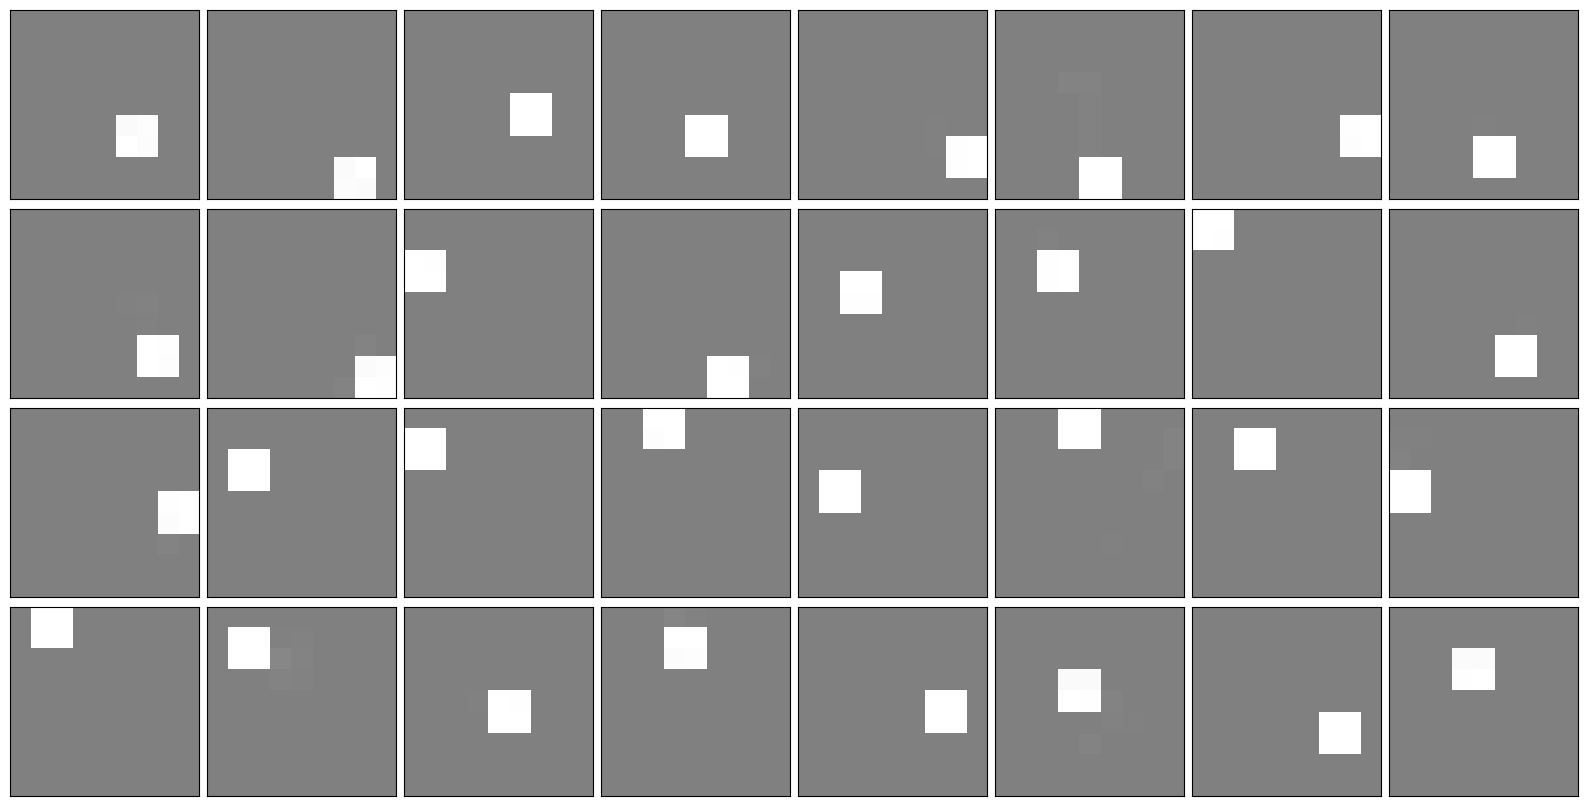

In [10]:
_ = plot_gallery(V.detach().numpy().reshape(-1,*data_dims), n_row=4, n_col = 8)